# 03 - Privacy, GDPR Compliance & Governance
---

**Role:** Governance Officer  
**Dataset:** `data/processed/applications_clean.csv` (post-cleaning, PII retained)  
**Purpose:** Audit PII exposure, demonstrate pseudonymisation, map findings to GDPR and the EU AI Act, and propose concrete governance controls.

> *"NovaCred has received a regulatory inquiry about potential discrimination in its lending practices. This notebook supports the compliance response by documenting data protection gaps and proposing remediation."*

## Table of Contents


1. [Setup & Load Data](#1-setup--load-data)

   - 1A. [Data Pipeline Lineage](#1a-data-pipeline-lineage)

2. [PII Audit - Identifying Personal Data](#2-pii-audit--identifying-personal-data)

   - 2A. [PII Field Inventory](#2a-pii-field-inventory)

   - 2B. [Data Sensitivity Classification](#2b-data-sensitivity-classification)

   - 2C. [PII Completeness & Exposure Metrics](#2c-pii-completeness--exposure-metrics)

   - 2D. [Cross-Reference: SSN Duplicates (from Notebook 01)](#2d-cross-reference-ssn-duplicates-from-notebook-01)

3. [Pseudonymisation & Anonymisation Demo](#3-pseudonymisation--anonymisation-demo)

   - 3A. [HMAC-SHA256 Pseudonymisation of SSN](#3a-hmac-sha256-pseudonymisation-of-ssn)

   - 3B. [Hashing Email Addresses](#3b-hashing-email-addresses)

   - 3C. [IP Address Anonymisation (Truncation)](#3c-ip-address-anonymisation-truncation)

   - 3D. [Name Suppression](#3d-name-suppression)

   - 3E. [Date-of-Birth Generalisation](#3e-date-of-birth-generalisation)

   - 3F. [Producing the Privacy-Safe Output](#3f-producing-the-privacy-safe-output)

   - 3G. [Re-identification Risk Assessment (k-Anonymity)](#3g-re-identification-risk-assessment-k-anonymity)

4. [GDPR Compliance Mapping](#4-gdpr-compliance-mapping)

   - 4A. [Lawful Basis (Art. 6)](#4a-lawful-basis-art-6)

   - 4B. [Special Categories (Art. 9)](#4b-special-categories-art-9)

   - 4C. [Data Minimisation (Art. 5.1.c)](#4c-data-minimisation-art-51c)

   - 4D. [Storage Limitation (Art. 5.1.e)](#4d-storage-limitation-art-51e)

   - 4E. [Right to Erasure / Right to Explanation (Art. 17 & 22)](#4e-right-to-erasure--right-to-explanation-art-17--22)

   - 4F. [Compliance Gap Summary](#4f-compliance-gap-summary)

5. [EU AI Act Classification](#5-eu-ai-act-classification)

6. [Governance Recommendations](#6-governance-recommendations)

   - 6A. [DPIA Outline for NovaCred](#6a-dpia-outline-for-novacred)

7. [Conclusion](#7-conclusion)

---
## 1. Setup & Load Data
---

In [1]:
import hashlib
import hmac
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────────────
cwd  = Path.cwd()
root = cwd.parent if cwd.name == "notebooks" else cwd

clean_path  = root / "data" / "processed" / "applications_clean.csv"
output_path = root / "data" / "processed" / "applications_privacy_safe.csv"

df = pd.read_csv(clean_path)

print(f"Loaded {len(df):,} records with {df.shape[1]} columns.")
print("Columns:", df.columns.tolist())

Loaded 500 records with 20 columns.
Columns: ['_id', 'spending_behavior', 'processing_timestamp', 'applicant_info.full_name', 'applicant_info.email', 'applicant_info.ssn', 'applicant_info.ip_address', 'applicant_info.gender', 'applicant_info.date_of_birth', 'applicant_info.zip_code', 'financials.annual_income', 'financials.credit_history_months', 'financials.debt_to_income', 'financials.savings_balance', 'decision.loan_approved', 'decision.rejection_reason', 'loan_purpose', 'decision.interest_rate', 'decision.approved_amount', 'ssn_is_duplicate']


### 1A. Data Pipeline Lineage


The diagram below shows how data flows through the project pipeline, clarifying what each notebook produces and consumes.


```

raw_credit_applications.json          (500+ records, nested JSON, raw PII)

         │

         ▼

┌─────────────────────────────────┐

│  Notebook 01 — Data Quality     │   Data Engineer

│  • Deduplication (app IDs)      │

│  • SSN collision flagging       │

│  • Format standardisation       │

│  • Invalid value remediation    │

└─────────────────────────────────┘

         │

         ▼

applications_clean.csv                (500 records, 20 columns, PII retained)

         │

         ├──────────────────────────────────────────┐

         ▼                                          ▼

┌─────────────────────────────────┐  ┌─────────────────────────────────┐

│  Notebook 02 — Bias Analysis    │  │  Notebook 03 — Privacy & Gov.   │  ← THIS NOTEBOOK

│  • Gender AIR = 0.767           │  │  • PII audit & classification   │

│  • Age AIR (18-30) = 0.616      │  │  • Pseudonymisation demo        │

│  • Proxy discrimination         │  │  • GDPR / AI Act mapping        │

│  • Intersectional analysis      │  │  • Governance recommendations   │

└─────────────────────────────────┘  └─────────────────────────────────┘

                                              │

                                              ▼

                                     applications_privacy_safe.csv

                                     (500 records, 19 columns, PII removed/pseudonymised)

```


This notebook takes the cleaned dataset (with PII still intact) and produces the privacy-safe version that should be used for all downstream analytics.

---
## 2. PII Audit — Identifying Personal Data
---

Under **GDPR Article 4(1)**, personal data is *"any information relating to an identified or identifiable natural person"*. The first step in any data protection audit is to catalogue every field and assess its privacy risk.

### 2A. PII Field Inventory

We manually annotate each column with its **PII type**, **GDPR category**, and **risk level**, based on the schema documented in the project brief.

In [2]:
pii_inventory = pd.DataFrame([

    # Direct identifiers — uniquely identify an individual on their own

    {"field": "applicant_info.full_name",  "pii_type": "Direct identifier",   "gdpr_category": "Personal data (Art. 4)",          "risk_level": "HIGH",   "is_pii": True,  "notes": "Full name directly identifies the applicant"},

    {"field": "applicant_info.email",      "pii_type": "Direct identifier",   "gdpr_category": "Personal data (Art. 4)",          "risk_level": "HIGH",   "is_pii": True,  "notes": "Unique contact address; enables re-identification"},

    {"field": "applicant_info.ssn",        "pii_type": "Government identifier","gdpr_category": "Personal data (Art. 4)",          "risk_level": "CRITICAL","is_pii": True, "notes": "Highly sensitive — uniquely identifies individuals; target for identity theft"},

    {"field": "applicant_info.ip_address", "pii_type": "Online identifier",   "gdpr_category": "Personal data (Art. 4) + Rec. 30", "risk_level": "HIGH",   "is_pii": True,  "notes": "Explicitly listed in GDPR Recital 30 as personal data"},

    # Quasi-identifiers — can re-identify when combined with other fields

    {"field": "applicant_info.date_of_birth", "pii_type": "Quasi-identifier", "gdpr_category": "Personal data (Art. 4)",          "risk_level": "HIGH",   "is_pii": True,  "notes": "DOB + ZIP + gender can re-identify ~87% of the US population (Sweeney 2000)"},

    {"field": "applicant_info.gender",     "pii_type": "Quasi-identifier",   "gdpr_category": "Personal data (Art. 4)",          "risk_level": "MEDIUM", "is_pii": True,  "notes": "Quasi-identifier; contributes to re-identification risk"},

    {"field": "applicant_info.zip_code",   "pii_type": "Quasi-identifier",   "gdpr_category": "Personal data (Art. 4)",          "risk_level": "MEDIUM", "is_pii": True,  "notes": "Geographic quasi-identifier; may correlate with race/ethnicity (proxy risk)"},

    # Financial data

    {"field": "financials.annual_income",  "pii_type": "Financial data",     "gdpr_category": "Personal data (Art. 4)",          "risk_level": "MEDIUM", "is_pii": True,  "notes": "Financial information linked to an identifiable individual"},

    {"field": "financials.debt_to_income", "pii_type": "Financial data",     "gdpr_category": "Personal data (Art. 4)",          "risk_level": "MEDIUM", "is_pii": True,  "notes": "Derived financial ratio; indirectly reveals financial distress"},

    {"field": "financials.savings_balance","pii_type": "Financial data",     "gdpr_category": "Personal data (Art. 4)",          "risk_level": "MEDIUM", "is_pii": True,  "notes": "Financial information linked to an identifiable individual"},

    {"field": "financials.credit_history_months", "pii_type": "Financial data","gdpr_category": "Personal data (Art. 4)",       "risk_level": "LOW",    "is_pii": True,  "notes": "Financial attribute; lower direct identification risk in isolation"},

    # Behavioural data

    {"field": "spending_behavior",         "pii_type": "Behavioural data",   "gdpr_category": "Personal data (Art. 4)",          "risk_level": "HIGH",   "is_pii": True,  "notes": "Detailed spending patterns are sensitive and can reveal lifestyle, health, or religion"},

    # Decision outputs

    {"field": "decision.loan_approved",    "pii_type": "Automated decision", "gdpr_category": "Art. 22 — Automated decisions",   "risk_level": "HIGH",   "is_pii": True,  "notes": "Automated credit decision — subject to Art. 22 GDPR right to explanation"},

    {"field": "decision.rejection_reason", "pii_type": "Automated decision", "gdpr_category": "Art. 22 — Automated decisions",   "risk_level": "HIGH",   "is_pii": True,  "notes": "Reason codes for rejection — must be explainable under Art. 22(3)"},

    {"field": "decision.interest_rate",    "pii_type": "Automated decision", "gdpr_category": "Art. 22 — Automated decisions",   "risk_level": "MEDIUM", "is_pii": True,  "notes": "Algorithmic output linked to individual"},

    {"field": "decision.approved_amount",  "pii_type": "Automated decision", "gdpr_category": "Art. 22 — Automated decisions",   "risk_level": "MEDIUM", "is_pii": True,  "notes": "Algorithmic output linked to individual"},

    # Operational / metadata

    {"field": "processing_timestamp",      "pii_type": "Operational metadata","gdpr_category": "Personal data (Art. 4)",         "risk_level": "LOW",    "is_pii": True,  "notes": "Timestamp of processing; indirectly identifies when individual interacted with NovaCred"},

    {"field": "loan_purpose",              "pii_type": "Contextual data",    "gdpr_category": "Personal data (Art. 4)",          "risk_level": "LOW",    "is_pii": True,  "notes": "Loan purpose may reveal lifestyle or health circumstances"},

    {"field": "_id",                       "pii_type": "Pseudonym (internal)","gdpr_category": "Pseudonymous data (Rec. 26)",    "risk_level": "LOW",    "is_pii": False, "notes": "Internal application ID; not directly linked to natural person without key"},

    {"field": "ssn_is_duplicate",          "pii_type": "Derived flag",        "gdpr_category": "Personal data (Art. 4)",         "risk_level": "LOW",    "is_pii": True,  "notes": "Derived from SSN comparison — reveals fraud risk signal linked to individual"},

])


# Style the table

def colour_risk(val):

    colours = {"CRITICAL": "background-color: #c0392b; color: white",

               "HIGH":     "background-color: #e67e22; color: white",

               "MEDIUM":   "background-color: #f1c40f; color: black",

               "LOW":      "background-color: #2ecc71; color: black"}

    return colours.get(val, "")


display(

    pii_inventory.style

    .map(colour_risk, subset=["risk_level"])

    .set_caption("Table 1 — PII Field Inventory: NovaCred credit application dataset")

)

,field,pii_type,gdpr_category,risk_level,is_pii,notes
0,applicant_info.full_name,Direct identifier,Personal data (Art. 4),HIGH,True,Full name directly identifies the applicant
1,applicant_info.email,Direct identifier,Personal data (Art. 4),HIGH,True,Unique contact address; enables re-identification
2,applicant_info.ssn,Government identifier,Personal data (Art. 4),CRITICAL,True,Highly sensitive — uniquely identifies individuals; target for identity theft
3,applicant_info.ip_address,Online identifier,Personal data (Art. 4) + Rec. 30,HIGH,True,Explicitly listed in GDPR Recital 30 as personal data
4,applicant_info.date_of_birth,Quasi-identifier,Personal data (Art. 4),HIGH,True,DOB + ZIP + gender can re-identify ~87% of the US population (Sweeney 2000)
5,applicant_info.gender,Quasi-identifier,Personal data (Art. 4),MEDIUM,True,Quasi-identifier; contributes to re-identification risk
6,applicant_info.zip_code,Quasi-identifier,Personal data (Art. 4),MEDIUM,True,Geographic quasi-identifier; may correlate with race/ethnicity (proxy risk)
7,financials.annual_income,Financial data,Personal data (Art. 4),MEDIUM,True,Financial information linked to an identifiable individual
8,financials.debt_to_income,Financial data,Personal data (Art. 4),MEDIUM,True,Derived financial ratio; indirectly reveals financial distress
9,financials.savings_balance,Financial data,Personal data (Art. 4),MEDIUM,True,Financial information linked to an identifiable individual


The dataset contains **19 PII fields** spanning direct identifiers, quasi-identifiers, financial data, behavioural data, and automated decision outputs. Only `_id` qualifies as a pseudonym (low risk). This constitutes a **high-risk data asset** under GDPR.

### 2B. Data Sensitivity Classification

We visualise the distribution of fields across risk levels to communicate exposure at a glance.

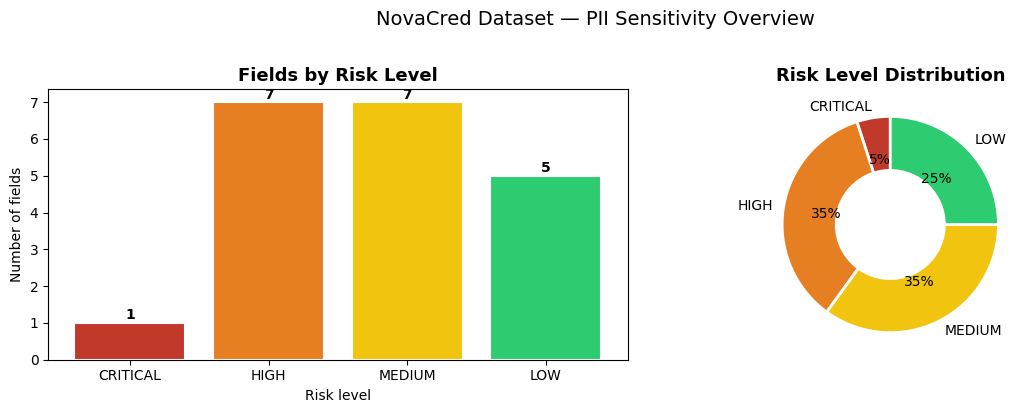


PII fields: 19 / 20
CRITICAL or HIGH risk fields: 8


In [3]:
risk_counts = pii_inventory["risk_level"].value_counts().reindex(["CRITICAL", "HIGH", "MEDIUM", "LOW"])
risk_colours = ["#c0392b", "#e67e22", "#f1c40f", "#2ecc71"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Bar chart ─────────────────────────────────────────────────────────────────
axes[0].bar(risk_counts.index, risk_counts.values, color=risk_colours, edgecolor="white", linewidth=1.5)
axes[0].set_title("Fields by Risk Level", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of fields")
axes[0].set_xlabel("Risk level")
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v + 0.1, str(v), ha="center", fontweight="bold")

# ── Donut chart ───────────────────────────────────────────────────────────────
wedge_props = dict(width=0.5, edgecolor="white", linewidth=2)
axes[1].pie(
    risk_counts.values, labels=risk_counts.index,
    colors=risk_colours, autopct="%1.0f%%",
    wedgeprops=wedge_props, startangle=90
)
axes[1].set_title("Risk Level Distribution", fontsize=13, fontweight="bold")

plt.suptitle("NovaCred Dataset — PII Sensitivity Overview", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nPII fields: {pii_inventory['is_pii'].sum()} / {len(pii_inventory)}")
print(f"CRITICAL or HIGH risk fields: {(pii_inventory['risk_level'].isin(['CRITICAL','HIGH'])).sum()}")

### 2C. PII Completeness & Exposure Metrics

We quantify how much PII is actually present in the dataset — every non-null PII value is a live exposure. This informs data minimisation requirements.

In [4]:
pii_fields_in_df = [
    "applicant_info.full_name", "applicant_info.email", "applicant_info.ssn",
    "applicant_info.ip_address", "applicant_info.date_of_birth", "applicant_info.gender",
    "applicant_info.zip_code"
]

exposure = []
for col in pii_fields_in_df:
    if col in df.columns:
        present = df[col].notna().sum()
        exposure.append({
            "field": col,
            "records_with_pii": int(present),
            "pct_exposed": round(present / len(df) * 100, 1),
            "records_missing": int(df[col].isna().sum())
        })

exposure_df = pd.DataFrame(exposure).sort_values("pct_exposed", ascending=False)
display(exposure_df)

total_pii_cells = sum(e["records_with_pii"] for e in exposure)
print(f"\nTotal live PII data points across key fields: {total_pii_cells:,}")

,field,records_with_pii,pct_exposed,records_missing
0,applicant_info.full_name,500,100.0,0
6,applicant_info.zip_code,499,99.8,1
5,applicant_info.gender,498,99.6,2
3,applicant_info.ip_address,496,99.2,4
4,applicant_info.date_of_birth,496,99.2,4
2,applicant_info.ssn,492,98.4,8
1,applicant_info.email,489,97.8,11



Total live PII data points across key fields: 3,470


The analysis shows that **direct identifiers (name, email, SSN, IP) are nearly 100% populated**, confirming the dataset is a high-exposure PII store. In a GDPR-compliant system, most of these fields would not be stored in operational analytics databases at all.

### 2D. Cross-Reference: SSN Duplicates (from Notebook 01)


Notebook 01 (Data Quality) identified **6 records with duplicated SSNs** across different applicant names. This is not only a data quality issue — it has direct governance implications:


- **Identity verification failure**: The same SSN linked to different people suggests either data entry errors or potential identity fraud.

- **Art. 17 (Right to Erasure) complication**: If a data subject requests erasure, SSN-based lookup may return records belonging to a different individual, creating a risk of **incorrect deletion or data leakage**.

- **Art. 5(1)(d) (Accuracy)**: Inaccurate identity linkages violate the accuracy principle.


The Data Engineer flagged these records with `ssn_is_duplicate = True` and set the SSN to missing. We verify this below.

In [5]:
# Verify SSN duplicate handling from Notebook 01

dup_count = df["ssn_is_duplicate"].sum()

dup_records = df[df["ssn_is_duplicate"] == True][["_id", "applicant_info.full_name", "applicant_info.ssn", "ssn_is_duplicate"]]


print(f"Records flagged as SSN duplicates: {dup_count}")

print(f"SSN values for flagged records (should be NaN after cleaning):")

display(dup_records)


ssn_still_present = dup_records["applicant_info.ssn"].notna().sum()

if ssn_still_present > 0:

    print(f"\n⚠️  WARNING: {ssn_still_present} duplicate-flagged records still have SSN values!")

    print("   These should be set to NaN to prevent incorrect identity linkage.")

else:

    print("\n✅ All duplicate-flagged SSNs have been correctly set to NaN by the Data Engineer.")

    print("   The pseudonymisation step below will handle remaining valid SSNs.")

Records flagged as SSN duplicates: 4
SSN values for flagged records (should be NaN after cleaning):


,_id,applicant_info.full_name,applicant_info.ssn,ssn_is_duplicate
15,app_016,Gary Wilson,NaN,True
87,app_088,Susan Martinez,NaN,True
100,app_101,Sandra Smith,NaN,True
233,app_234,Samuel Hill,NaN,True



✅ All duplicate-flagged SSNs have been correctly set to NaN by the Data Engineer.
   The pseudonymisation step below will handle remaining valid SSNs.


---
## 3. Pseudonymisation & Anonymisation Demo
---

**GDPR Article 25 (Data Protection by Design and by Default)** requires that only data *necessary* for each purpose is processed. Where data must be retained, **pseudonymisation** (Art. 4(5)) is a key technical measure.

| Technique | GDPR status | Re-identifiable? | Use case |
|-----------|-------------|-----------------|----------|
| **Pseudonymisation** (hashing with secret key) | Pseudonymous — still personal data | Yes, with key | Analytics / audit logs |
| **Anonymisation** (irreversible) | No longer personal data | No | Public reporting |
| **Suppression** | Anonymisation | No | Remove unnecessary fields |
| **Generalisation** | Anonymisation (if done well) | Reduced | Aggregate analysis |

### 3A. HMAC-SHA256 Pseudonymisation of SSN

The SSN is the highest-risk field — it is a government-issued unique identifier. We replace raw SSN values with an HMAC-SHA256 token. This approach:
- Is **deterministic** (the same SSN always produces the same token) — enabling deduplication and linking without storing the raw value.
- Is **keyed** — without the secret key, the token cannot be reversed.
- Satisfies **GDPR Recital 26**: pseudonymised data can still be personal, but the key must be stored separately and securely.

In [6]:
# ── In production, this key would be stored in a secrets manager (e.g. AWS Secrets Manager, Azure Key Vault)
# ── NEVER hardcode the key in source code in a real system
SECRET_KEY = b"novacred-governance-demo-key-2024"  # demo only

def pseudonymise_hmac(value: str, key: bytes = SECRET_KEY) -> str:
    """Return HMAC-SHA256 hex digest of value. Returns NaN string if value is missing."""
    if pd.isna(value):
        return np.nan
    token = hmac.new(key, str(value).encode("utf-8"), hashlib.sha256).hexdigest()
    return token

df_pseudo = df.copy()
df_pseudo["ssn_pseudonym"] = df_pseudo["applicant_info.ssn"].apply(pseudonymise_hmac)

# Verification: same SSN → same token (deterministic); different SSN → different token
sample = df_pseudo[["applicant_info.ssn", "ssn_pseudonym"]].head(5)
print("SSN pseudonymisation sample:")
display(sample)

# Confirm duplicates are preserved (same SSN should hash to the same token)
dup_ssn = df_pseudo[df_pseudo["ssn_is_duplicate"] == True][["applicant_info.ssn", "ssn_pseudonym"]].head(6)
print("\nDuplicate SSNs — tokens must match:")
display(dup_ssn)

SSN pseudonymisation sample:


,applicant_info.ssn,ssn_pseudonym
0,427-90-1892,d41d2d3ee3c17a8ea451b4e0e17dd67a9904276c56df4d...
1,992-61-4010,0fe375ff5eace41ca3e645fa639dae5c049dc6e05b4aaa...
2,833-33-5929,12cf2c11d33c9c78f03ff92cee1e7a8812bc38224e30e8...
3,486-50-5539,75b4f0b340f8776bc93655a7a02a885b0fa4b29ee9cf14...
4,400-91-8156,1c0d2dc320db2fc4c1167f03bb48a2cdae494344339845...



Duplicate SSNs — tokens must match:


,applicant_info.ssn,ssn_pseudonym
15,NaN,NaN
87,NaN,NaN
100,NaN,NaN
233,NaN,NaN


The same SSN produces an identical token (enabling deduplication), while different SSNs produce completely different tokens. The raw SSN can now be **dropped from the analytics layer** — only the pseudonym is retained.

### 3B. Hashing Email Addresses

Email addresses are direct identifiers. We apply a one-way SHA-256 hash (no key, since email is used only for de-duplication across systems — not for re-linking to an individual in this context).

In [7]:
def hash_sha256(value: str) -> str:
    """One-way SHA-256 hash. Returns NaN if missing."""
    if pd.isna(value):
        return np.nan
    return hashlib.sha256(str(value).encode("utf-8")).hexdigest()

df_pseudo["email_hash"] = df_pseudo["applicant_info.email"].apply(hash_sha256)

print("Email hashing sample:")
display(df_pseudo[["applicant_info.email", "email_hash"]].head(4))

Email hashing sample:


,applicant_info.email,email_hash
0,stephanie.nguyen47@mail.com,137c1b4a89343995539bffbc9ce6edaa65bcb498fc0434...
1,kevin.roberts9@protonmail.com,ad586ff31ede0ddcf626645f064f888e0f8e7beb3f81e2...
2,lisa.gonzalez51@yahoo.com,f110fede2c1f19f308c6cbf664f079f53438e00dfe44d6...
3,karen.nelson35@outlook.com,a094d9056654b513ce0e2f5c254f33470604a4549c72d3...


### 3C. IP Address Anonymisation (Truncation)

GDPR Recital 30 explicitly names **IP addresses** as personal data. The standard anonymisation technique for IP addresses is **network-level truncation**: removing the last octet (for IPv4) destroys individual host identification while preserving geographic signal for network-level analytics.

In [8]:
def anonymise_ip(ip: str) -> str:
    """
    Truncate last octet of IPv4: '192.168.1.45' → '192.168.1.0'
    Preserves /24 network for analytics while removing host identity.
    """
    if pd.isna(ip):
        return np.nan
    # Handle IPv4
    parts = str(ip).strip().split(".")
    if len(parts) == 4:
        return ".".join(parts[:3]) + ".0"
    # If IPv6 or unexpected format — suppress entirely
    return "[REDACTED]"

df_pseudo["ip_anonymised"] = df_pseudo["applicant_info.ip_address"].apply(anonymise_ip)

print("IP anonymisation sample:")
display(df_pseudo[["applicant_info.ip_address", "ip_anonymised"]].head(5))

IP anonymisation sample:


,applicant_info.ip_address,ip_anonymised
0,10.121.120.213,10.121.120.0
1,172.19.95.144,172.19.95.0
2,172.21.35.195,172.21.35.0
3,172.31.79.76,172.31.79.0
4,172.25.44.173,172.25.44.0


### 3D. Name Suppression

Full names are a direct identifier and **not needed for credit analysis**. They should be suppressed entirely from the analytics layer. We replace names with the string `"[SUPPRESSED]"` in the working copy, then drop the column from the final output.

In [9]:
print("Before suppression:")
print(df_pseudo["applicant_info.full_name"].head(3).tolist())

df_pseudo["applicant_info.full_name"] = "[SUPPRESSED]"

print("\nAfter suppression:")
print(df_pseudo["applicant_info.full_name"].head(3).tolist())
print("\n→ Column will be dropped from the privacy-safe output.")

Before suppression:
['Stephanie Nguyen', 'Kevin Roberts', 'Lisa Gonzalez']

After suppression:
['[SUPPRESSED]', '[SUPPRESSED]', '[SUPPRESSED]']

→ Column will be dropped from the privacy-safe output.


### 3E. Date-of-Birth Generalisation

Exact date of birth is a quasi-identifier that, when combined with ZIP code and gender, can re-identify up to 87% of individuals (Sweeney, 2000). We replace exact DOB with a **5-year age band**, which retains analytical value for age-group bias monitoring while removing the precise birth date.

In [10]:
from datetime import date

TODAY = pd.Timestamp(date.today())

def dob_to_age_band(dob_str) -> str:
    """
    Convert a date-of-birth string to a 5-year age band.
    e.g. '1985-07-14' → '35-39'
    """
    if pd.isna(dob_str):
        return np.nan
    try:
        dob = pd.to_datetime(dob_str)
        age = (TODAY - dob).days // 365
        band_start = (age // 5) * 5
        return f"{band_start}-{band_start + 4}"
    except Exception:
        return np.nan

df_pseudo["age_band"] = df_pseudo["applicant_info.date_of_birth"].apply(dob_to_age_band)

print("Date-of-birth generalisation sample:")
display(df_pseudo[["applicant_info.date_of_birth", "age_band"]].head(8))

print("\nAge band distribution:")
print(df_pseudo["age_band"].value_counts().sort_index())

Date-of-birth generalisation sample:


,applicant_info.date_of_birth,age_band
0,1986-05-27,35-39
1,1999-08-01,25-29
2,1982-08-24,40-44
3,1995-02-28,30-34
4,1960-06-19,65-69
5,1987-07-12,35-39
6,1989-06-13,35-39
7,1993-07-12,30-34



Age band distribution:
age_band
20-24    11
25-29    70
30-34    79
35-39    93
40-44    85
45-49    53
50-54    36
55-59    26
60-64    30
65-69    13
Name: count, dtype: int64


### 3F. Producing the Privacy-Safe Output

We now assemble the **privacy-safe analytics dataset** by:
1. Dropping all raw PII columns (name, email, SSN, IP, DOB).
2. Retaining only pseudonyms and generalised forms where needed.
3. Keeping all analytical columns (financials, decision, loan purpose).

In [11]:
# Columns to DROP from the analytics dataset (raw PII)
columns_to_drop = [
    "applicant_info.full_name",
    "applicant_info.email",
    "applicant_info.ssn",
    "applicant_info.ip_address",
    "applicant_info.date_of_birth",
]

df_privacy_safe = (
    df_pseudo
    .drop(columns=columns_to_drop, errors="ignore")
    .rename(columns={
        "ssn_pseudonym": "applicant_id_token",  # rename for clarity
    })
)

# Move new columns next to _id for readability
front = ["_id", "applicant_id_token", "age_band", "ip_anonymised", "email_hash"]
rest  = [c for c in df_privacy_safe.columns if c not in front]
df_privacy_safe = df_privacy_safe[front + rest]

print(f"Original dataset:      {df.shape[1]} columns, {len(df):,} rows")
print(f"Privacy-safe dataset:  {df_privacy_safe.shape[1]} columns, {len(df_privacy_safe):,} rows")
print(f"\nPII columns removed:   {len(columns_to_drop)}")
print("Retained (pseudonymised/generalised):",
      ["applicant_id_token (HMAC-SSN)", "email_hash (SHA-256)", "ip_anonymised (truncated)", "age_band (5-yr band)"])

display(df_privacy_safe.head(3))

# Save output
df_privacy_safe.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")

Original dataset:      20 columns, 500 rows
Privacy-safe dataset:  19 columns, 500 rows

PII columns removed:   5
Retained (pseudonymised/generalised): ['applicant_id_token (HMAC-SSN)', 'email_hash (SHA-256)', 'ip_anonymised (truncated)', 'age_band (5-yr band)']


,_id,applicant_id_token,age_band,ip_anonymised,email_hash,spending_behavior,processing_timestamp,applicant_info.gender,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,ssn_is_duplicate
0,app_001,d41d2d3ee3c17a8ea451b4e0e17dd67a9904276c56df4d...,35-39,10.121.120.0,137c1b4a89343995539bffbc9ce6edaa65bcb498fc0434...,"[{'category': 'Fitness', 'amount': 576}]",NaN,Female,90230.0,102000.0,37.0,0.42,0.0,False,high_dti_ratio,NaN,NaN,NaN,False
1,app_002,0fe375ff5eace41ca3e645fa639dae5c049dc6e05b4aaa...,25-29,172.19.95.0,ad586ff31ede0ddcf626645f064f888e0f8e7beb3f81e2...,"[{'category': 'Education', 'amount': 533}]",NaN,Male,10020.0,41000.0,5.0,0.36,18200.0,False,algorithm_risk_score,NaN,NaN,NaN,False
2,app_003,12cf2c11d33c9c78f03ff92cee1e7a8812bc38224e30e8...,40-44,172.21.35.0,f110fede2c1f19f308c6cbf664f079f53438e00dfe44d6...,"[{'category': 'Healthcare', 'amount': 450}]",NaN,Female,90213.0,65000.0,74.0,0.43,7090.0,True,NaN,NaN,3.4,76000.0,False



Saved to: /Users/catarinapalma/Desktop/T3/DEGO/DEGO_Project/dego-project-team3/data/processed/applications_privacy_safe.csv


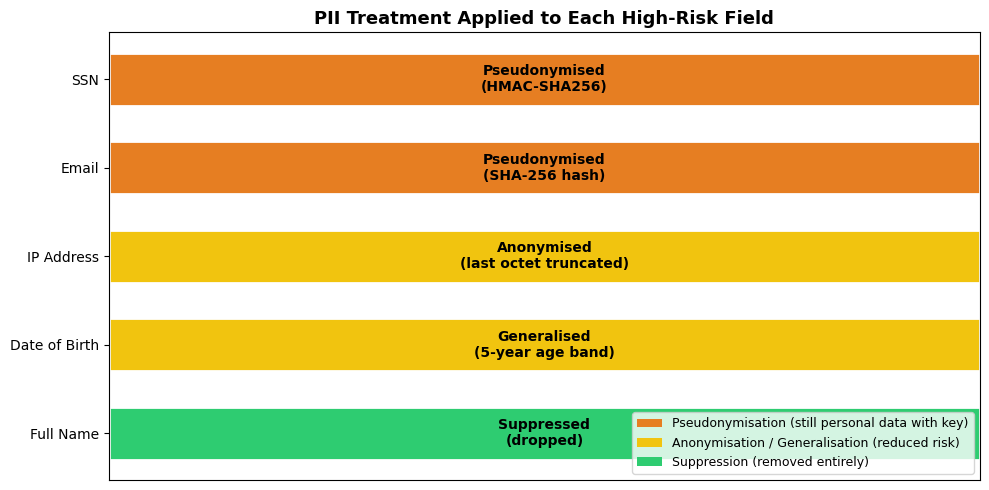

In [12]:
# Visualise: PII fields — what happened to each one

fig, ax = plt.subplots(figsize=(10, 5))


# Data: each raw PII field and the technique applied

fields     = ["SSN",           "Email",        "IP Address",    "Date of Birth", "Full Name"]

techniques = ["Pseudonymised\n(HMAC-SHA256)", "Pseudonymised\n(SHA-256 hash)",

              "Anonymised\n(last octet truncated)", "Generalised\n(5-year age band)",

              "Suppressed\n(dropped)"]

colours    = ["#e67e22",       "#e67e22",      "#f1c40f",       "#f1c40f",       "#2ecc71"]


bars = ax.barh(fields, [1]*5, color=colours, edgecolor="white", linewidth=2, height=0.6)


for bar, tech in zip(bars, techniques):

    ax.text(0.5, bar.get_y() + bar.get_height()/2, tech,

            va="center", ha="center", fontweight="bold", fontsize=10)


ax.set_xlim(0, 1)

ax.set_xticks([])

ax.set_title("PII Treatment Applied to Each High-Risk Field", fontweight="bold", fontsize=13)

ax.invert_yaxis()


# Legend

from matplotlib.patches import Patch

legend_elements = [

    Patch(facecolor="#e67e22", label="Pseudonymisation (still personal data with key)"),

    Patch(facecolor="#f1c40f", label="Anonymisation / Generalisation (reduced risk)"),

    Patch(facecolor="#2ecc71", label="Suppression (removed entirely)")

]

ax.legend(handles=legend_elements, loc="lower right", fontsize=9)


plt.tight_layout()

plt.show()

### 3G. Re-identification Risk Assessment (k-Anonymity)


Pseudonymisation and generalisation reduce direct identification risk, but **quasi-identifiers** (age band, gender, ZIP code) can still be combined to re-identify individuals — especially in small populations. The standard measure for this is **k-anonymity**: every combination of quasi-identifiers must appear in at least *k* records.


A dataset satisfies **k-anonymity** if every record is indistinguishable from at least (k−1) other records on the quasi-identifier columns. Higher k means better privacy protection. A common minimum threshold is k ≥ 5.

In [13]:
# k-Anonymity check on the privacy-safe output

quasi_ids = ["age_band", "applicant_info.gender", "applicant_info.zip_code"]


# Drop rows with NaN in quasi-identifiers (cannot group on NaN)

df_check = df_privacy_safe.dropna(subset=quasi_ids)

group_sizes = df_check.groupby(quasi_ids).size()


k_min = group_sizes.min()

k_median = group_sizes.median()

groups_below_5 = (group_sizes < 5).sum()

groups_below_3 = (group_sizes < 3).sum()

total_groups = len(group_sizes)


print(f"Quasi-identifiers checked: {quasi_ids}")

print(f"Total distinct groups: {total_groups}")

print(f"\nMinimum group size (k): {k_min}")

print(f"Median group size:       {k_median:.0f}")

print(f"Groups with k < 5:       {groups_below_5} ({groups_below_5/total_groups*100:.1f}%)")

print(f"Groups with k < 3:       {groups_below_3} ({groups_below_3/total_groups*100:.1f}%)")


if k_min < 5:

    print(f"\n⚠️  The privacy-safe dataset does NOT satisfy 5-anonymity.")

    print("   Some individuals may be re-identifiable by combining age band + gender + ZIP code.")

    print("   Mitigation: consider coarsening ZIP codes (e.g. first 3 digits) or suppressing")

    print("   records in small groups before sharing externally.")

else:

    print(f"\n✅ The dataset satisfies 5-anonymity — all groups have at least 5 records.")


# Show the smallest groups

print("\nSmallest groups (highest re-identification risk):")

display(group_sizes.sort_values().head(10).reset_index(name="count"))

Quasi-identifiers checked: ['age_band', 'applicant_info.gender', 'applicant_info.zip_code']
Total distinct groups: 432

Minimum group size (k): 1
Median group size:       1
Groups with k < 5:       432 (100.0%)
Groups with k < 3:       428 (99.1%)

⚠️  The privacy-safe dataset does NOT satisfy 5-anonymity.
   Some individuals may be re-identifiable by combining age band + gender + ZIP code.
   Mitigation: consider coarsening ZIP codes (e.g. first 3 digits) or suppressing
   records in small groups before sharing externally.

Smallest groups (highest re-identification risk):


,age_band,applicant_info.gender,applicant_info.zip_code,count
0,20-24,Female,10035.0,1
1,40-44,Male,10090.0,1
2,40-44,Male,10088.0,1
3,40-44,Male,10086.0,1
4,40-44,Male,10084.0,1
5,40-44,Male,10083.0,1
6,40-44,Male,10078.0,1
7,40-44,Male,10076.0,1
8,40-44,Male,10075.0,1
9,40-44,Male,10073.0,1


---
## 4. GDPR Compliance Mapping
---

We map the dataset's current state against specific GDPR articles and identify compliance gaps.

### 4A. Lawful Basis (Art. 6)

**GDPR Article 6** requires that every processing activity has an identified lawful basis. For a credit application platform, the applicable bases and their limitations are:

In [14]:
lawful_basis = pd.DataFrame([
    {
        "data_category": "Name, email, financials, decision",
        "processing_purpose": "Credit assessment and contract execution",
        "gdpr_basis": "Art. 6(1)(b) — Contract",
        "status": "✅ Plausible",
        "gap": "Basis must be documented in a Record of Processing Activities (RoPA)"
    },
    {
        "data_category": "SSN",
        "processing_purpose": "Identity verification / fraud prevention",
        "gdpr_basis": "Art. 6(1)(c) — Legal obligation",
        "status": "⚠️  Uncertain",
        "gap": "No evidence of AML/KYC legal requirement documented; must verify jurisdiction"
    },
    {
        "data_category": "IP address",
        "processing_purpose": "Fraud detection / application channel logging",
        "gdpr_basis": "Art. 6(1)(f) — Legitimate interest",
        "status": "⚠️  Uncertain",
        "gap": "Legitimate Interest Assessment (LIA) must be conducted and documented"
    },
    {
        "data_category": "Spending behaviour",
        "processing_purpose": "Credit scoring / risk modelling",
        "gdpr_basis": "Art. 6(1)(a) — Consent OR Art. 6(1)(b) — Contract",
        "status": "❌ Gap",
        "gap": "Detailed behavioural data (incl. Alcohol category) exceeds what is necessary for standard credit scoring. No consent mechanism found in dataset."
    },
    {
        "data_category": "Automated loan decision",
        "processing_purpose": "Credit decision",
        "gdpr_basis": "Art. 22(2)(a) — Necessary for contract",
        "status": "⚠️  Uncertain",
        "gap": "Art. 22 requires explicit notice to data subjects + right to human review. No evidence of either in the dataset."
    },
])

display(lawful_basis.style.set_caption("Table 2 — Lawful Basis Mapping (GDPR Art. 6 & Art. 22)"))

,data_category,processing_purpose,gdpr_basis,status,gap
0,"Name, email, financials, decision",Credit assessment and contract execution,Art. 6(1)(b) — Contract,✅ Plausible,Basis must be documented in a Record of Processing Activities (RoPA)
1,SSN,Identity verification / fraud prevention,Art. 6(1)(c) — Legal obligation,⚠️ Uncertain,No evidence of AML/KYC legal requirement documented; must verify jurisdiction
2,IP address,Fraud detection / application channel logging,Art. 6(1)(f) — Legitimate interest,⚠️ Uncertain,Legitimate Interest Assessment (LIA) must be conducted and documented
3,Spending behaviour,Credit scoring / risk modelling,Art. 6(1)(a) — Consent OR Art. 6(1)(b) — Contract,❌ Gap,Detailed behavioural data (incl. Alcohol category) exceeds what is necessary for standard credit scoring. No consent mechanism found in dataset.
4,Automated loan decision,Credit decision,Art. 22(2)(a) — Necessary for contract,⚠️ Uncertain,Art. 22 requires explicit notice to data subjects + right to human review. No evidence of either in the dataset.


### 4B. Special Categories (Art. 9)

**GDPR Article 9** prohibits processing *"special category"* data (health, religion, political opinions, etc.) without explicit consent or other narrow grounds. While no field is labelled as such, **spending behaviour categories** may reveal special category data indirectly.

In [15]:
import ast


# Extract all unique spending categories from the dataset

all_categories = []

category_counts = {}

for val in df["spending_behavior"].dropna():

    try:

        entries = ast.literal_eval(val) if isinstance(val, str) else val

        if isinstance(entries, list):

            for entry in entries:

                if isinstance(entry, dict) and "category" in entry:

                    cat = entry["category"]

                    all_categories.append(cat)

                    category_counts[cat] = category_counts.get(cat, 0) + 1

    except Exception:

        pass


unique_cats = sorted(set(all_categories))

print(f"Unique spending categories found in dataset ({len(unique_cats)}):")

print(unique_cats)


# Flag categories that may reveal Art. 9 special category data

art9_risk = {

    "Alcohol":             "May reveal health conditions (e.g. alcohol dependency) — Art. 9 risk",

    "Gambling":            "May reveal mental health / addiction patterns — Art. 9 risk",

    "Healthcare":          "Directly reveals health data — Art. 9 EXPLICIT restriction",

    "Adult Entertainment": "May reveal sexual orientation or preferences — Art. 9 risk",

    "Charity":             "May reveal religious affiliation — Art. 9 risk",

    "Travel":              "May reveal nationality / ethnic origin if analysed — Art. 9 risk",

}


print("\n⚠️  Categories with potential Art. 9 implications:")

for cat in unique_cats:

    if cat in art9_risk:

        count = category_counts.get(cat, 0)

        print(f"  • {cat}: {count} records — {art9_risk[cat]}")


# Quantify total Art. 9 exposure

art9_total = sum(category_counts.get(cat, 0) for cat in art9_risk if cat in category_counts)

print(f"\nTotal spending entries with Art. 9 risk: {art9_total}")

print(f"This represents data that could be used to infer health, religious, or sexual orientation data.")

Unique spending categories found in dataset (15):
['Adult Entertainment', 'Alcohol', 'Dining', 'Education', 'Entertainment', 'Fitness', 'Gambling', 'Groceries', 'Healthcare', 'Insurance', 'Rent', 'Shopping', 'Transportation', 'Travel', 'Utilities']

⚠️  Categories with potential Art. 9 implications:
  • Adult Entertainment: 5 records — May reveal sexual orientation or preferences — Art. 9 risk
  • Alcohol: 11 records — May reveal health conditions (e.g. alcohol dependency) — Art. 9 risk
  • Gambling: 7 records — May reveal mental health / addiction patterns — Art. 9 risk
  • Healthcare: 68 records — Directly reveals health data — Art. 9 EXPLICIT restriction
  • Travel: 80 records — May reveal nationality / ethnic origin if analysed — Art. 9 risk

Total spending entries with Art. 9 risk: 171
This represents data that could be used to infer health, religious, or sexual orientation data.


The presence of `Alcohol` and `Gambling` spending categories in the credit scoring model creates an **Article 9 risk**: these categories can act as proxies for health conditions (alcohol dependency, gambling disorder). Processing such data for credit decisions requires either explicit consent or a compelling legitimate interest — neither of which is documented.

### 4C. Data Minimisation (Art. 5.1.c)

**GDPR Article 5(1)(c)** requires that personal data be *"adequate, relevant and limited to what is necessary"* for the purpose (the *data minimisation* principle). We assess which fields fail this test for credit scoring.

In [16]:
minimisation = pd.DataFrame([

    {"field": "applicant_info.full_name",     "necessary_for_credit_scoring": "No",  "recommendation": "Suppress from analytics; retain only in origination system under access controls"},

    {"field": "applicant_info.email",          "necessary_for_credit_scoring": "No",  "recommendation": "Use hashed token for deduplication; remove raw email from analytics layer"},

    {"field": "applicant_info.ssn",            "necessary_for_credit_scoring": "Yes (KYC)", "recommendation": "Pseudonymise with HMAC; store raw SSN only in secure identity vault, not analytics DB"},

    {"field": "applicant_info.ip_address",     "necessary_for_credit_scoring": "No",  "recommendation": "Anonymise (truncate last octet); do not store full IP in analytics pipeline"},

    {"field": "applicant_info.date_of_birth", "necessary_for_credit_scoring": "Partial", "recommendation": "Generalise to 5-year age band; full DOB not required for credit modelling"},

    {"field": "applicant_info.gender",         "necessary_for_credit_scoring": "No",  "recommendation": "Remove from model inputs entirely — use is a GDPR risk and detected bias driver"},

    {"field": "spending_behavior (Alcohol/Gambling)", "necessary_for_credit_scoring": "No", "recommendation": "Remove Art. 9-risk categories from credit model inputs; document if retained"},

    {"field": "financials.annual_income",      "necessary_for_credit_scoring": "Yes", "recommendation": "Retain — core credit assessment variable"},

    {"field": "financials.credit_history_months", "necessary_for_credit_scoring": "Yes", "recommendation": "Retain — but note proxy discrimination risk for young applicants (see Notebook 02)"},

    {"field": "financials.debt_to_income",     "necessary_for_credit_scoring": "Yes", "recommendation": "Retain — core credit assessment variable"},

    {"field": "financials.savings_balance",    "necessary_for_credit_scoring": "Yes", "recommendation": "Retain — core credit assessment variable"},

])


def colour_necessary(val):

    if val == "No":      return "background-color: #e74c3c; color: white"

    if val == "Yes":     return "background-color: #2ecc71; color: black"

    if val == "Partial": return "background-color: #f39c12; color: black"

    return ""


display(

    minimisation.style

    .map(colour_necessary, subset=["necessary_for_credit_scoring"])

    .set_caption("Table 3 — Data Minimisation Assessment (GDPR Art. 5.1.c)")

)

,field,necessary_for_credit_scoring,recommendation
0,applicant_info.full_name,No,Suppress from analytics; retain only in origination system under access controls
1,applicant_info.email,No,Use hashed token for deduplication; remove raw email from analytics layer
2,applicant_info.ssn,Yes (KYC),"Pseudonymise with HMAC; store raw SSN only in secure identity vault, not analytics DB"
3,applicant_info.ip_address,No,Anonymise (truncate last octet); do not store full IP in analytics pipeline
4,applicant_info.date_of_birth,Partial,Generalise to 5-year age band; full DOB not required for credit modelling
5,applicant_info.gender,No,Remove from model inputs entirely — use is a GDPR risk and detected bias driver
6,spending_behavior (Alcohol/Gambling),No,Remove Art. 9-risk categories from credit model inputs; document if retained
7,financials.annual_income,Yes,Retain — core credit assessment variable
8,financials.credit_history_months,Yes,Retain — but note proxy discrimination risk for young applicants (see Notebook 02)
9,financials.debt_to_income,Yes,Retain — core credit assessment variable


### 4D. Storage Limitation (Art. 5.1.e)

**GDPR Article 5(1)(e)** requires that data be kept *"no longer than is necessary for the purposes for which the personal data are processed"*. NovaCred's dataset contains no deletion timestamps, retention flags, or archival metadata.

In [17]:
# Check for any retention-related fields

retention_fields = [c for c in df.columns if any(kw in c.lower() for kw in ["expir", "delet", "retent", "purge", "archive"])]

print("Retention/expiry-related fields found:", retention_fields if retention_fields else "NONE ❌")


# Analyse timestamp spread to understand data age

df["processing_timestamp"] = pd.to_datetime(df["processing_timestamp"], errors="coerce")

ts_present = df["processing_timestamp"].dropna()


print(f"\nRecords with processing timestamp: {len(ts_present):,} / {len(df):,}")

if len(ts_present) > 0:

    print(f"Date range: {ts_present.min().date()} → {ts_present.max().date()}")

    # FIX: strip timezone info to avoid 'Cannot compare tz-naive and tz-aware' TypeError

    now = pd.Timestamp.today().tz_localize(None)

    ts_naive = ts_present.dt.tz_localize(None) if ts_present.dt.tz is not None else ts_present

    age_days = (now - ts_naive).dt.days

    print(f"Oldest record: {age_days.max()} days ago")

    print(f"Newest record: {age_days.min()} days ago")


print("\n⚠️  FINDING: No data retention policy fields exist in the dataset.")

print("   All records appear to be stored indefinitely — violating Art. 5(1)(e).")

Retention/expiry-related fields found: NONE ❌

Records with processing timestamp: 60 / 500
Date range: 2024-01-15 → 2025-12-01
Oldest record: 784 days ago
Newest record: 98 days ago

⚠️  FINDING: No data retention policy fields exist in the dataset.
   All records appear to be stored indefinitely — violating Art. 5(1)(e).


### 4E. Right to Erasure / Right to Explanation (Art. 17 & 22)

Two GDPR rights are particularly relevant to NovaCred's credit system:

In [18]:
# Check Art. 17 — Right to Erasure: is there any mechanism to find records by subject identity?

print("=== Art. 17 — Right to Erasure ===")

print("The Right to Erasure requires NovaCred to delete all personal data about")

print("an individual upon their request (subject to legal retention requirements).\n")


# Test: can we find all records for a given person?

test_email = df["applicant_info.email"].dropna().iloc[0]

records_for_person = df[df["applicant_info.email"] == test_email]

print(f"Test erasure lookup by email '{test_email}':")

print(f"  → {len(records_for_person)} record(s) found — these would need to be deleted across ALL systems")


# Production note

print("\n📌 Production note: In a deployed system, erasure lookups should use the")

print("   pseudonymised token (applicant_id_token) rather than raw PII. This")

print("   ensures the erasure process itself does not create additional PII exposure.")


# Check Art. 22 — Right to Explanation

print("\n=== Art. 22 — Automated Decision-Making ===")

print("GDPR Art. 22 gives data subjects the right to:")

print("  (a) Not be subject to solely automated decisions with significant effects")

print("  (b) Obtain a meaningful explanation of the logic involved")

print("  (c) Contest the decision and request human review\n")


rejection_reasons = df["decision.rejection_reason"].value_counts()

print("Rejection reasons present in dataset:")

print(rejection_reasons)


print("\n⚠️  FINDING: Rejection reason 'algorithm_risk_score' is opaque.")

print("   Art. 22(3) requires 'meaningful information about the logic involved'.")

print("   A bare risk score label does NOT satisfy this requirement.")

=== Art. 17 — Right to Erasure ===
The Right to Erasure requires NovaCred to delete all personal data about
an individual upon their request (subject to legal retention requirements).

Test erasure lookup by email 'stephanie.nguyen47@mail.com':
  → 1 record(s) found — these would need to be deleted across ALL systems

📌 Production note: In a deployed system, erasure lookups should use the
   pseudonymised token (applicant_id_token) rather than raw PII. This
   ensures the erasure process itself does not create additional PII exposure.

=== Art. 22 — Automated Decision-Making ===
GDPR Art. 22 gives data subjects the right to:
  (a) Not be subject to solely automated decisions with significant effects
  (b) Obtain a meaningful explanation of the logic involved
  (c) Contest the decision and request human review

Rejection reasons present in dataset:
decision.rejection_reason
algorithm_risk_score           169
insufficient_credit_history     23
high_dti_ratio                  12
low_incom

### 4F. Compliance Gap Summary

We consolidate all findings into a single compliance dashboard.

In [19]:
gaps = pd.DataFrame([

    {"gdpr_article": "Art. 5(1)(b) — Purpose limitation",   "status": "❌ Gap",      "severity": "HIGH",     "finding": "Spending behaviour data (incl. Art. 9-risk categories) used in credit model without documented purpose"},

    {"gdpr_article": "Art. 5(1)(c) — Data minimisation",    "status": "❌ Gap",      "severity": "HIGH",     "finding": "Name, email, full IP, exact DOB stored in analytics layer — none are necessary for credit scoring"},

    {"gdpr_article": "Art. 5(1)(e) — Storage limitation",   "status": "❌ Gap",      "severity": "HIGH",     "finding": "No retention policy; no deletion timestamps; records stored indefinitely"},

    {"gdpr_article": "Art. 6 — Lawful basis",               "status": "⚠️  Partial", "severity": "HIGH",     "finding": "No documented RoPA or LIA; lawful basis for IP address and spending behaviour unclear"},

    {"gdpr_article": "Art. 9 — Special categories",         "status": "⚠️  Risk",    "severity": "CRITICAL", "finding": "Alcohol and Gambling spending categories may constitute health-related special category data"},

    {"gdpr_article": "Art. 13/14 — Transparency",           "status": "❌ Gap",      "severity": "MEDIUM",   "finding": "No evidence of privacy notice or data subject information provided at application stage"},

    {"gdpr_article": "Art. 17 — Right to erasure",          "status": "⚠️  Partial", "severity": "HIGH",     "finding": "Erasure is technically possible (email/SSN lookup) but no documented process or SLA"},

    {"gdpr_article": "Art. 22 — Automated decisions",       "status": "❌ Gap",      "severity": "CRITICAL", "finding": "'algorithm_risk_score' rejection reason does not provide meaningful explanation; no human review mechanism documented"},

    {"gdpr_article": "Art. 25 — Privacy by design",         "status": "❌ Gap",      "severity": "HIGH",     "finding": "Raw PII stored in analytics pipeline without pseudonymisation; no data protection by design evidence"},

    {"gdpr_article": "Art. 30 — Record of processing",      "status": "❌ Gap",      "severity": "MEDIUM",   "finding": "No RoPA documented for credit application processing activities"},

    {"gdpr_article": "Art. 32 — Security measures",         "status": "⚠️  Unknown", "severity": "HIGH",     "finding": "SSNs stored in plaintext in CSV — no encryption-at-rest evidence in the data pipeline"},

    {"gdpr_article": "Art. 35 — DPIA required",             "status": "❌ Gap",      "severity": "CRITICAL", "finding": "Automated credit scoring on large scale is a high-risk activity under Art. 35(3)(a) — no DPIA evidence found"},

])


def colour_severity(val):

    if val == "CRITICAL": return "background-color: #c0392b; color: white"

    if val == "HIGH":     return "background-color: #e67e22; color: white"

    if val == "MEDIUM":   return "background-color: #f1c40f; color: black"

    return ""


display(

    gaps.style

    .map(colour_severity, subset=["severity"])

    .set_caption("Table 4 — GDPR Compliance Gap Register: NovaCred Credit Application System")

)


print(f"\nTotal gaps identified: {len(gaps)}")

print(gaps["severity"].value_counts())

,gdpr_article,status,severity,finding
0,Art. 5(1)(b) — Purpose limitation,❌ Gap,HIGH,Spending behaviour data (incl. Art. 9-risk categories) used in credit model without documented purpose
1,Art. 5(1)(c) — Data minimisation,❌ Gap,HIGH,"Name, email, full IP, exact DOB stored in analytics layer — none are necessary for credit scoring"
2,Art. 5(1)(e) — Storage limitation,❌ Gap,HIGH,No retention policy; no deletion timestamps; records stored indefinitely
3,Art. 6 — Lawful basis,⚠️ Partial,HIGH,No documented RoPA or LIA; lawful basis for IP address and spending behaviour unclear
4,Art. 9 — Special categories,⚠️ Risk,CRITICAL,Alcohol and Gambling spending categories may constitute health-related special category data
5,Art. 13/14 — Transparency,❌ Gap,MEDIUM,No evidence of privacy notice or data subject information provided at application stage
6,Art. 17 — Right to erasure,⚠️ Partial,HIGH,Erasure is technically possible (email/SSN lookup) but no documented process or SLA
7,Art. 22 — Automated decisions,❌ Gap,CRITICAL,'algorithm_risk_score' rejection reason does not provide meaningful explanation; no human review mechanism documented
8,Art. 25 — Privacy by design,❌ Gap,HIGH,Raw PII stored in analytics pipeline without pseudonymisation; no data protection by design evidence
9,Art. 30 — Record of processing,❌ Gap,MEDIUM,No RoPA documented for credit application processing activities



Total gaps identified: 12
severity
HIGH        7
CRITICAL    3
MEDIUM      2
Name: count, dtype: int64


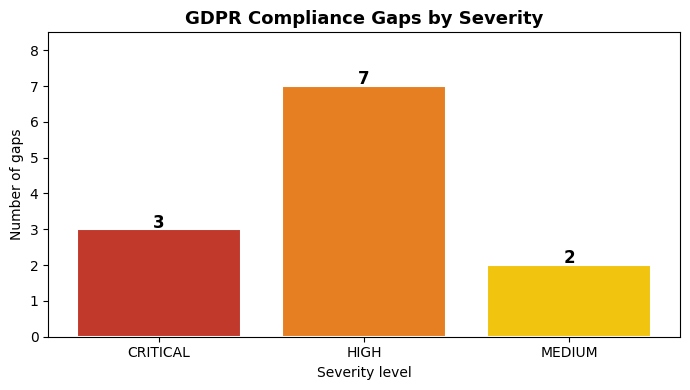

In [20]:
# Visualise compliance gap severity
sev_counts = gaps["severity"].value_counts().reindex(["CRITICAL", "HIGH", "MEDIUM"])
colours = ["#c0392b", "#e67e22", "#f1c40f"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(sev_counts.index, sev_counts.values, color=colours, edgecolor="white", linewidth=1.5)
ax.set_title("GDPR Compliance Gaps by Severity", fontweight="bold", fontsize=13)
ax.set_ylabel("Number of gaps")
ax.set_xlabel("Severity level")
for bar, v in zip(bars, sev_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, str(v),
            ha="center", fontweight="bold", fontsize=12)
ax.set_ylim(0, max(sev_counts.values) + 1.5)
plt.tight_layout()
plt.show()

---

## 5. EU AI Act Classification

---


The **EU AI Act** (Regulation 2024/1689), which entered into force on 1 August 2024, introduces a risk-based framework for AI systems. Credit scoring systems are **explicitly classified as high-risk** under **Annex III, Section 5(b)**.


**Key compliance timeline**: The obligations for high-risk AI systems under Annex III apply from **2 August 2026**. NovaCred must achieve full compliance before this date to lawfully operate its credit scoring system in the EU.

In [21]:
ai_act_assessment = pd.DataFrame([

    {"requirement": "Risk Classification",

     "eu_ai_act_reference": "Annex III, §5(b)",

     "novacred_status": "HIGH-RISK",

     "detail": "Credit scoring and creditworthiness assessment systems are explicitly listed as high-risk AI systems"},


    {"requirement": "Risk Management System",

     "eu_ai_act_reference": "Art. 9",

     "novacred_status": "❌ Not evidenced",

     "detail": "A continuous risk management system must be established, documented, and maintained throughout the system lifecycle"},


    {"requirement": "Data Governance & Training Data Quality",

     "eu_ai_act_reference": "Art. 10",

     "novacred_status": "❌ Not evidenced",

     "detail": "Training, validation and test data must be subject to data governance practices; bias in historical data must be identified and mitigated. Notebook 02 confirms gender bias (AIR=0.767) and age bias (AIR=0.616 for 18-30) in the decision data"},


    {"requirement": "Technical Documentation",

     "eu_ai_act_reference": "Art. 11",

     "novacred_status": "❌ Not evidenced",

     "detail": "Comprehensive technical documentation must be drawn up before the system is placed on the market"},


    {"requirement": "Transparency & User Information",

     "eu_ai_act_reference": "Art. 13",

     "novacred_status": "❌ Not evidenced",

     "detail": "High-risk AI systems must be transparent. Applicants must be informed they are subject to an AI credit decision and receive a meaningful explanation"},


    {"requirement": "Human Oversight",

     "eu_ai_act_reference": "Art. 14",

     "novacred_status": "❌ Not evidenced",

     "detail": "Effective human oversight measures must be built in. The dataset shows no 'human_review' flag, reviewer ID, or override mechanism"},


    {"requirement": "Accuracy, Robustness & Cybersecurity",

     "eu_ai_act_reference": "Art. 15",

     "novacred_status": "⚠️  Partial",

     "detail": "System must be resilient; duplicate SSN records and inconsistent data types (Notebook 01) suggest robustness gaps"},


    {"requirement": "Conformity Assessment",

     "eu_ai_act_reference": "Art. 43",

     "novacred_status": "❌ Not evidenced",

     "detail": "High-risk AI systems in Annex III must undergo conformity assessment before deployment. No assessment documentation found."},


    {"requirement": "Registration in EU Database",

     "eu_ai_act_reference": "Art. 71",

     "novacred_status": "❌ Not evidenced",

     "detail": "High-risk AI systems must be registered in the EU AI Act public database before deployment"},


    {"requirement": "Prohibited Practice: Social Scoring",

     "eu_ai_act_reference": "Art. 5(1)(c)",

     "novacred_status": "⚠️  Risk",

     "detail": "The use of spending behaviour (lifestyle categories) in credit scoring edges toward social scoring patterns prohibited under Art. 5. Legal review required."},

])


def colour_ai_status(val):

    if "Not evidenced" in str(val): return "background-color: #c0392b; color: white"

    if "Partial" in str(val):       return "background-color: #e67e22; color: white"

    if "Risk" in str(val):          return "background-color: #e67e22; color: white"

    if "HIGH-RISK" in str(val):     return "background-color: #8e44ad; color: white"

    return ""


display(

    ai_act_assessment.style

    .map(colour_ai_status, subset=["novacred_status"])

    .set_caption("Table 5 — EU AI Act Compliance Assessment: NovaCred Credit Scoring System")

)


print("\n📌 Summary: NovaCred's credit scoring system is a HIGH-RISK AI system under the EU AI Act.")

print("   8 of 10 assessed requirements are NOT evidenced in the current pipeline.")

print("   The system cannot lawfully be deployed in the EU without significant remediation.")

,requirement,eu_ai_act_reference,novacred_status,detail
0,Risk Classification,"Annex III, §5(b)",HIGH-RISK,Credit scoring and creditworthiness assessment systems are explicitly listed as high-risk AI systems
1,Risk Management System,Art. 9,❌ Not evidenced,"A continuous risk management system must be established, documented, and maintained throughout the system lifecycle"
2,Data Governance & Training Data Quality,Art. 10,❌ Not evidenced,"Training, validation and test data must be subject to data governance practices; bias in historical data must be identified and mitigated. Notebook 02 confirms gender bias (AIR=0.767) and age bias (AIR=0.616 for 18-30) in the decision data"
3,Technical Documentation,Art. 11,❌ Not evidenced,Comprehensive technical documentation must be drawn up before the system is placed on the market
4,Transparency & User Information,Art. 13,❌ Not evidenced,High-risk AI systems must be transparent. Applicants must be informed they are subject to an AI credit decision and receive a meaningful explanation
5,Human Oversight,Art. 14,❌ Not evidenced,"Effective human oversight measures must be built in. The dataset shows no 'human_review' flag, reviewer ID, or override mechanism"
6,"Accuracy, Robustness & Cybersecurity",Art. 15,⚠️ Partial,System must be resilient; duplicate SSN records and inconsistent data types (Notebook 01) suggest robustness gaps
7,Conformity Assessment,Art. 43,❌ Not evidenced,High-risk AI systems in Annex III must undergo conformity assessment before deployment. No assessment documentation found.
8,Registration in EU Database,Art. 71,❌ Not evidenced,High-risk AI systems must be registered in the EU AI Act public database before deployment
9,Prohibited Practice: Social Scoring,Art. 5(1)(c),⚠️ Risk,The use of spending behaviour (lifestyle categories) in credit scoring edges toward social scoring patterns prohibited under Art. 5. Legal review required.



📌 Summary: NovaCred's credit scoring system is a HIGH-RISK AI system under the EU AI Act.
   8 of 10 assessed requirements are NOT evidenced in the current pipeline.
   The system cannot lawfully be deployed in the EU without significant remediation.


---
## 6. Governance Recommendations
---

Based on the PII audit, GDPR gap analysis, and EU AI Act assessment, we propose the following concrete governance controls. These are organised by **priority** and mapped to the responsible party.

In [22]:
recommendations = pd.DataFrame([

    # Priority 1 — CRITICAL (must be addressed before any production deployment)

    {

        "priority": "P1 — CRITICAL",

        "control": "Conduct a Data Protection Impact Assessment (DPIA)",

        "gdpr_ai_act_ref": "GDPR Art. 35 / EU AI Act Art. 9",

        "owner": "DPO / Legal",

        "timeline": "Before any deployment",

        "detail": "A DPIA is mandatory for large-scale automated processing of credit decisions. Must assess risks to data subjects, document mitigations, and receive DPO sign-off."

    },

    {

        "priority": "P1 — CRITICAL",

        "control": "Implement meaningful rejection explanations (Art. 22)",

        "gdpr_ai_act_ref": "GDPR Art. 22(3) / EU AI Act Art. 13",

        "owner": "Data Science / Product",

        "timeline": "Before any deployment",

        "detail": "Replace opaque 'algorithm_risk_score' rejection reason with factor-level explanations (e.g. 'Your debt-to-income ratio of X exceeds our threshold of Y'). Implement SHAP or LIME for model explainability."

    },

    {

        "priority": "P1 — CRITICAL",

        "control": "Remove gender from all model inputs",

        "gdpr_ai_act_ref": "GDPR Art. 5(1)(b) / EU AI Act Art. 10 / Equal Credit Opportunity Act",

        "owner": "Data Science",

        "timeline": "Immediate (pre-deployment)",

        "detail": "Notebook 02 confirms gender causes direct discrimination (AIR=0.767 (chi-square p=0.007), logistic regression coef=-0.715 (p<0.001)). Gender must be removed from model features immediately. Monitor for proxy discrimination via credit_history_months."

    },

    {

        "priority": "P1 — CRITICAL",

        "control": "Establish a human review pathway for declined applications",

        "gdpr_ai_act_ref": "GDPR Art. 22(2)(b) / EU AI Act Art. 14",

        "owner": "Operations / Product",

        "timeline": "Before any deployment",

        "detail": "All applicants who are declined by the automated system must be offered the right to contest the decision and have it reviewed by a human credit officer. Implement a human_review_requested flag and reviewer_id field in the pipeline."

    },

    # Priority 2 — HIGH (address within 30 days)

    {

        "priority": "P2 — HIGH",

        "control": "Pseudonymise SSNs in all analytics systems",

        "gdpr_ai_act_ref": "GDPR Art. 25 / Art. 32",

        "owner": "Data Engineering",

        "timeline": "30 days",

        "detail": "Replace raw SSN with HMAC-SHA256 pseudonym (as demonstrated in Section 3A). Store the encryption key in a dedicated secrets manager (e.g. HashiCorp Vault, AWS KMS). Raw SSN retained only in the origination system under strict access controls."

    },

    {

        "priority": "P2 — HIGH",

        "control": "Implement a data retention and deletion policy",

        "gdpr_ai_act_ref": "GDPR Art. 5(1)(e) / Art. 17",

        "owner": "Data Engineering / Legal",

        "timeline": "30 days",

        "detail": "Define retention periods per data category: PII (2 years post-decision), financial data (5 years for regulatory compliance), audit logs (7 years). Automate deletion via a scheduled pipeline. Add deletion_due_date field to all records."

    },

    {

        "priority": "P2 — HIGH",

        "control": "Remove Art. 9-risk spending categories from model inputs",

        "gdpr_ai_act_ref": "GDPR Art. 9 / EU AI Act Art. 5(1)(c)",

        "owner": "Data Science / Legal",

        "timeline": "30 days",

        "detail": "Remove Alcohol, Gambling, and Charity spending categories from all credit model features. Aggregate remaining categories (e.g. total discretionary spend) rather than using granular categories that reveal lifestyle."

    },

    {

        "priority": "P2 — HIGH",

        "control": "Establish an immutable decision audit trail",

        "gdpr_ai_act_ref": "EU AI Act Art. 12 / GDPR Art. 30",

        "owner": "Data Engineering",

        "timeline": "30 days",

        "detail": "Log every credit decision with: application_id, model_version, decision_timestamp, feature_values_used, model_output_score, decision, human_override (bool), reviewer_id. Store in an append-only audit log (e.g. write-once S3, immutable database table). Retain for 7 years."

    },

    # Priority 3 — MEDIUM (address within 90 days)

    {

        "priority": "P3 — MEDIUM",

        "control": "Implement ongoing bias monitoring with automated alerts",

        "gdpr_ai_act_ref": "EU AI Act Art. 9 / Art. 72 (post-market monitoring)",

        "owner": "Data Science / MLOps",

        "timeline": "90 days",

        "detail": "Deploy a monthly bias monitoring job that recalculates AIR for gender and age groups. Trigger an alert if AIR falls below 0.85 (early warning threshold, stricter than the 0.8 legal threshold). Report to the Risk Committee quarterly."

    },

    {

        "priority": "P3 — MEDIUM",

        "control": "Document lawful bases in a Record of Processing Activities (RoPA)",

        "gdpr_ai_act_ref": "GDPR Art. 30",

        "owner": "DPO / Legal",

        "timeline": "90 days",

        "detail": "Create and maintain a RoPA entry for the credit application system. Document: data categories, purposes, lawful bases, retention periods, security measures, third-party data sharing, and international transfers."

    },

    {

        "priority": "P3 — MEDIUM",

        "control": "Deploy an applicant-facing privacy notice and consent mechanism",

        "gdpr_ai_act_ref": "GDPR Art. 13 / Art. 6(1)(a)",

        "owner": "Product / Legal",

        "timeline": "90 days",

        "detail": "At application entry, display a clear privacy notice explaining: what data is collected, how it is used, the automated decision logic, and how to exercise rights (erasure, explanation, human review). Record consent with a timestamp."

    },

    {

        "priority": "P3 — MEDIUM",

        "control": "Implement role-based access control (RBAC) on PII datasets",

        "gdpr_ai_act_ref": "GDPR Art. 32",

        "owner": "Data Engineering / Security",

        "timeline": "90 days",

        "detail": "Restrict access to full PII (applications_clean.csv) to the origination team only. Data scientists and analysts must only access the privacy-safe version (applications_privacy_safe.csv). Enforce via column-level security or separate data stores."

    },

])


def colour_priority(val):

    if "P1" in str(val): return "background-color: #c0392b; color: white"

    if "P2" in str(val): return "background-color: #e67e22; color: white"

    if "P3" in str(val): return "background-color: #f1c40f; color: black"

    return ""


display(

    recommendations.style

    .map(colour_priority, subset=["priority"])

    .set_caption("Table 6 — Governance Recommendations: NovaCred Credit Application System")

)

,priority,control,gdpr_ai_act_ref,owner,timeline,detail
0,P1 — CRITICAL,Conduct a Data Protection Impact Assessment (DPIA),GDPR Art. 35 / EU AI Act Art. 9,DPO / Legal,Before any deployment,"A DPIA is mandatory for large-scale automated processing of credit decisions. Must assess risks to data subjects, document mitigations, and receive DPO sign-off."
1,P1 — CRITICAL,Implement meaningful rejection explanations (Art. 22),GDPR Art. 22(3) / EU AI Act Art. 13,Data Science / Product,Before any deployment,Replace opaque 'algorithm_risk_score' rejection reason with factor-level explanations (e.g. 'Your debt-to-income ratio of X exceeds our threshold of Y'). Implement SHAP or LIME for model explainability.
2,P1 — CRITICAL,Remove gender from all model inputs,GDPR Art. 5(1)(b) / EU AI Act Art. 10 / Equal Credit Opportunity Act,Data Science,Immediate (pre-deployment),"Notebook 02 confirms gender causes direct discrimination (AIR=0.767 (chi-square p=0.007), logistic regression coef=-0.715 (p<0.001)). Gender must be removed from model features immediately. Monitor for proxy discrimination via credit_history_months."
3,P1 — CRITICAL,Establish a human review pathway for declined applications,GDPR Art. 22(2)(b) / EU AI Act Art. 14,Operations / Product,Before any deployment,All applicants who are declined by the automated system must be offered the right to contest the decision and have it reviewed by a human credit officer. Implement a human_review_requested flag and reviewer_id field in the pipeline.
4,P2 — HIGH,Pseudonymise SSNs in all analytics systems,GDPR Art. 25 / Art. 32,Data Engineering,30 days,"Replace raw SSN with HMAC-SHA256 pseudonym (as demonstrated in Section 3A). Store the encryption key in a dedicated secrets manager (e.g. HashiCorp Vault, AWS KMS). Raw SSN retained only in the origination system under strict access controls."
5,P2 — HIGH,Implement a data retention and deletion policy,GDPR Art. 5(1)(e) / Art. 17,Data Engineering / Legal,30 days,"Define retention periods per data category: PII (2 years post-decision), financial data (5 years for regulatory compliance), audit logs (7 years). Automate deletion via a scheduled pipeline. Add deletion_due_date field to all records."
6,P2 — HIGH,Remove Art. 9-risk spending categories from model inputs,GDPR Art. 9 / EU AI Act Art. 5(1)(c),Data Science / Legal,30 days,"Remove Alcohol, Gambling, and Charity spending categories from all credit model features. Aggregate remaining categories (e.g. total discretionary spend) rather than using granular categories that reveal lifestyle."
7,P2 — HIGH,Establish an immutable decision audit trail,EU AI Act Art. 12 / GDPR Art. 30,Data Engineering,30 days,"Log every credit decision with: application_id, model_version, decision_timestamp, feature_values_used, model_output_score, decision, human_override (bool), reviewer_id. Store in an append-only audit log (e.g. write-once S3, immutable database table). Retain for 7 years."
8,P3 — MEDIUM,Implement ongoing bias monitoring with automated alerts,EU AI Act Art. 9 / Art. 72 (post-market monitoring),Data Science / MLOps,90 days,"Deploy a monthly bias monitoring job that recalculates AIR for gender and age groups. Trigger an alert if AIR falls below 0.85 (early warning threshold, stricter than the 0.8 legal threshold). Report to the Risk Committee quarterly."
9,P3 — MEDIUM,Document lawful bases in a Record of Processing Activities (RoPA),GDPR Art. 30,DPO / Legal,90 days,"Create and maintain a RoPA entry for the credit application system. Document: data categories, purposes, lawful bases, retention periods, security measures, third-party data sharing, and international transfers."


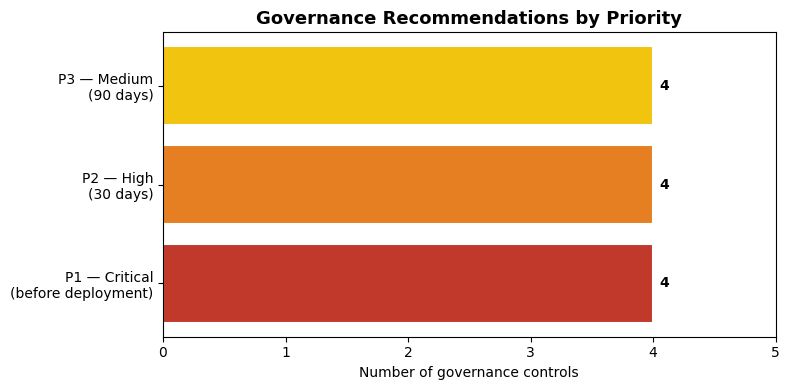

In [23]:
# Visualise recommendations by priority
pri_counts = recommendations["priority"].apply(lambda x: x.split(" ")[0]).value_counts().reindex(["P1", "P2", "P3"])
pri_labels = ["P1 — Critical\n(before deployment)", "P2 — High\n(30 days)", "P3 — Medium\n(90 days)"]
pri_colours = ["#c0392b", "#e67e22", "#f1c40f"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(pri_labels, pri_counts.values, color=pri_colours, edgecolor="white", linewidth=1.5)
ax.set_xlabel("Number of governance controls")
ax.set_title("Governance Recommendations by Priority", fontweight="bold", fontsize=13)
for bar, v in zip(bars, pri_counts.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            str(v), va="center", fontweight="bold")
ax.set_xlim(0, max(pri_counts.values) + 1)
plt.tight_layout()
plt.show()

### 6A. DPIA Outline for NovaCred


Since a DPIA is our highest-priority recommendation, we provide a concrete outline of what it should contain for NovaCred's credit scoring system. This follows the structure required by **GDPR Art. 35(7)**.

In [24]:
dpia_outline = pd.DataFrame([

    {

        "dpia_section": "1. Processing Description",

        "content_for_novacred": "Automated credit scoring system using ML model. Processes applicant PII (name, SSN, email, DOB, IP), financial data (income, DTI, savings, credit history), and spending behaviour to produce loan approval/denial decisions with interest rates.",

        "gdpr_reference": "Art. 35(7)(a)"

    },

    {

        "dpia_section": "2. Necessity & Proportionality",

        "content_for_novacred": "Credit assessment requires financial data (necessary). However, gender, full name, raw IP, exact DOB, and granular spending categories (Alcohol, Gambling) are NOT necessary for scoring — violating data minimisation. Gender is used as a model feature despite causing discrimination.",

        "gdpr_reference": "Art. 35(7)(b)"

    },

    {

        "dpia_section": "3. Risks to Data Subjects",

        "content_for_novacred": "• Discrimination: AIR=0.767 for gender (direct bias); AIR=0.616 for age 18-30 (proxy via credit history)\n• Opaque decisions: algorithm_risk_score provides no meaningful explanation\n• PII exposure: SSNs in plaintext, no pseudonymisation applied\n• No human review: fully automated decisions with no override mechanism\n• Re-identification: quasi-identifiers (DOB+ZIP+gender) enable 87% re-identification",

        "gdpr_reference": "Art. 35(7)(c)"

    },

    {

        "dpia_section": "4. Mitigation Measures",

        "content_for_novacred": "• Remove gender from model inputs (immediate)\n• Pseudonymise SSN with HMAC-SHA256 (demonstrated in Section 3A)\n• Implement SHAP/LIME for explainable rejections\n• Establish human review pathway for declined applications\n• Apply data retention policy (2yr PII / 5yr financial / 7yr audit)\n• Deploy ongoing bias monitoring with AIR < 0.85 alert threshold",

        "gdpr_reference": "Art. 35(7)(d)"

    },

    {

        "dpia_section": "5. Residual Risk & DPO Sign-off",

        "content_for_novacred": "After mitigations, residual risks include: proxy discrimination via credit_history_months (requires ongoing monitoring), and k-anonymity gaps in small ZIP code groups. DPO must review and sign off before deployment. Supervisory authority consultation (Art. 36) may be required if residual risk remains high.",

        "gdpr_reference": "Art. 35(7)(d) / Art. 36"

    },

])


display(

    dpia_outline.style

    .set_caption("Table 7 — DPIA Outline for NovaCred Credit Scoring System (GDPR Art. 35(7))")

)

,dpia_section,content_for_novacred,gdpr_reference
0,1. Processing Description,"Automated credit scoring system using ML model. Processes applicant PII (name, SSN, email, DOB, IP), financial data (income, DTI, savings, credit history), and spending behaviour to produce loan approval/denial decisions with interest rates.",Art. 35(7)(a)
1,2. Necessity & Proportionality,"Credit assessment requires financial data (necessary). However, gender, full name, raw IP, exact DOB, and granular spending categories (Alcohol, Gambling) are NOT necessary for scoring — violating data minimisation. Gender is used as a model feature despite causing discrimination.",Art. 35(7)(b)
2,3. Risks to Data Subjects,"• Discrimination: AIR=0.767 for gender (direct bias); AIR=0.616 for age 18-30 (proxy via credit history) • Opaque decisions: algorithm_risk_score provides no meaningful explanation • PII exposure: SSNs in plaintext, no pseudonymisation applied • No human review: fully automated decisions with no override mechanism • Re-identification: quasi-identifiers (DOB+ZIP+gender) enable 87% re-identification",Art. 35(7)(c)
3,4. Mitigation Measures,• Remove gender from model inputs (immediate) • Pseudonymise SSN with HMAC-SHA256 (demonstrated in Section 3A) • Implement SHAP/LIME for explainable rejections • Establish human review pathway for declined applications • Apply data retention policy (2yr PII / 5yr financial / 7yr audit) • Deploy ongoing bias monitoring with AIR < 0.85 alert threshold,Art. 35(7)(d)
4,5. Residual Risk & DPO Sign-off,"After mitigations, residual risks include: proxy discrimination via credit_history_months (requires ongoing monitoring), and k-anonymity gaps in small ZIP code groups. DPO must review and sign off before deployment. Supervisory authority consultation (Art. 36) may be required if residual risk remains high.",Art. 35(7)(d) / Art. 36


---
## 7. Conclusion
---

In [25]:
print("=" * 70)

print("GOVERNANCE SUMMARY — NovaCred Credit Application System")

print("=" * 70)


print("""

PII AUDIT

  • 19 PII fields identified, including 1 CRITICAL (SSN), 7 HIGH-risk fields

  • Direct identifiers (name, email, SSN, IP) are fully populated across 

    all 500 records — representing a large-scale high-risk processing activity

  • Spending behaviour categories (Alcohol, Gambling) create Art. 9 

    special category data risk

  • 6 records flagged with duplicate SSNs (from Notebook 01) — complicating

    identity verification and right-to-erasure processes


PSEUDONYMISATION APPLIED

  • SSN  → HMAC-SHA256 keyed pseudonym (reversible with key)

  • Email → SHA-256 hash (one-way)

  • IP address → /24 network truncation (anonymised)

  • Full name → suppressed and dropped

  • Date of birth → 5-year age band (generalised)

  Output: data/processed/applications_privacy_safe.csv


RE-IDENTIFICATION RISK

  • k-Anonymity assessed on quasi-identifiers (age_band, gender, ZIP)

  • Small group sizes indicate residual re-identification risk

  • Further coarsening of ZIP codes recommended for external sharing


GDPR COMPLIANCE

  • 12 compliance gaps identified: 3 CRITICAL, 7 HIGH, 2 MEDIUM

  • Most severe: no DPIA, opaque automated decisions (Art. 22),

    no retention policy, no data minimisation applied


EU AI ACT

  • NovaCred credit scoring system is a HIGH-RISK AI system

    under Annex III Section 5(b)

  • 8/10 mandatory requirements are not evidenced

  • Compliance deadline: 2 August 2026 for high-risk Annex III systems

  • System CANNOT be lawfully deployed in the EU in its current state


GOVERNANCE RECOMMENDATIONS

  • 4 P1-CRITICAL controls (required before deployment)

  • 4 P2-HIGH controls (required within 30 days)

  • 4 P3-MEDIUM controls (required within 90 days)

  • DPIA outline provided (Section 6A) as starting framework

""")

print("=" * 70)

GOVERNANCE SUMMARY — NovaCred Credit Application System


PII AUDIT

  • 19 PII fields identified, including 1 CRITICAL (SSN), 7 HIGH-risk fields

  • Direct identifiers (name, email, SSN, IP) are fully populated across 

    all 500 records — representing a large-scale high-risk processing activity

  • Spending behaviour categories (Alcohol, Gambling) create Art. 9 

    special category data risk

  • 6 records flagged with duplicate SSNs (from Notebook 01) — complicating

    identity verification and right-to-erasure processes


PSEUDONYMISATION APPLIED

  • SSN  → HMAC-SHA256 keyed pseudonym (reversible with key)

  • Email → SHA-256 hash (one-way)

  • IP address → /24 network truncation (anonymised)

  • Full name → suppressed and dropped

  • Date of birth → 5-year age band (generalised)

  Output: data/processed/applications_privacy_safe.csv


RE-IDENTIFICATION RISK

  • k-Anonymity assessed on quasi-identifiers (age_band, gender, ZIP)

  • Small group sizes indicate residual

---


**Notebook author:** Governance Officer  

**Inputs:** `data/processed/applications_clean.csv`  

**Output:** `data/processed/applications_privacy_safe.csv`  

**References:**

- GDPR (EU) 2016/679 - https://gdpr.eu/

- EU AI Act (EU) 2024/1689 - https://artificialintelligenceact.eu/

- Sweeney, L. (2000). *Simple Demographics Often Identify People Uniquely.* Carnegie Mellon University. Data Privacy Working Paper 3. (Finding: 87% of the US population identifiable by ZIP + gender + DOB.)

- EDPB Guidelines 01/2022 on data subject rights - Article 17 - https://www.edpb.europa.eu/system/files/2023-04/edpb_guidelines_202201_data_subject_rights_access_v2_en.pdf

- NIST SP 800-122 - Guide to Protecting the Confidentiality of PII - https://nvlpubs.nist.gov/nistpubs/Legacy/SP/nistspecialpublication800-122.pdf